<a href="https://colab.research.google.com/github/salih-salu/Loan_Approval_prediction_Machine_learning/blob/main/Load_approval_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib

In [90]:
df = pd.read_csv('/content/loan_data_1.csv')

In [91]:
df.isna().sum()

,0
Text,0
Income,0
Credit_Score,3
Loan_Amount,0
DTI_Ratio,0
Employment_Status,0
Approval,0


In [92]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
23995,False
23996,False
23997,False
23998,False


In [93]:
df

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581.0,8314,79.26,employed,Rejected
1,I want to make home improvements like installi...,197392,389.0,111604,22.14,employed,Rejected
2,"I need a loan for home renovation, including a...",44561,523.0,34118,45.44,employed,Rejected
3,I need funds to buy new furniture and applianc...,190363,729.0,118757,10.22,unemployed,Rejected
4,I need a loan to start a small business.,61853,732.0,19210,44.13,employed,Approved
...,...,...,...,...,...,...,...
23995,I need funds to pay for my daughter's college ...,195242,817.0,16403,24.32,employed,Approved
23996,I need financial assistance to launch my own Y...,150246,729.0,101572,9.97,employed,Rejected
23997,I need money to open a small bookstore and café.,64571,650.0,30533,57.35,employed,Rejected
23998,I want to buy a car for my rideshare business ...,115825,418.0,89837,10.37,unemployed,Rejected


In [94]:
df.drop(columns='Text', inplace=True)

In [95]:
df

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,26556,581.0,8314,79.26,employed,Rejected
1,197392,389.0,111604,22.14,employed,Rejected
2,44561,523.0,34118,45.44,employed,Rejected
3,190363,729.0,118757,10.22,unemployed,Rejected
4,61853,732.0,19210,44.13,employed,Approved
...,...,...,...,...,...,...
23995,195242,817.0,16403,24.32,employed,Approved
23996,150246,729.0,101572,9.97,employed,Rejected
23997,64571,650.0,30533,57.35,employed,Rejected
23998,115825,418.0,89837,10.37,unemployed,Rejected


# Checking the data types of the input columns

In [96]:
df.dtypes

,0
Income,int64
Credit_Score,float64
Loan_Amount,int64
DTI_Ratio,float64
Employment_Status,object
Approval,object


In [97]:
df.isna().sum()

,0
Income,0
Credit_Score,3
Loan_Amount,0
DTI_Ratio,0
Employment_Status,0
Approval,0


In [98]:
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].mean())

In [99]:
df.isna().sum()

,0
Income,0
Credit_Score,0
Loan_Amount,0
DTI_Ratio,0
Employment_Status,0
Approval,0


In [100]:
df['Employment_Status'].unique()

array(['employed', 'unemployed'], dtype=object)

In [101]:
encoder_emp_status = LabelEncoder()
df['Employment_Status'] = encoder_emp_status.fit_transform(df['Employment_Status'])


In [102]:
encoder_approval = LabelEncoder()
df['Approval'] = encoder_approval.fit_transform(df['Approval'])

Recheck the data types

In [103]:
df.dtypes

,0
Income,int64
Credit_Score,float64
Loan_Amount,int64
DTI_Ratio,float64
Employment_Status,int64
Approval,int64


In [104]:
df['Approval'].value_counts()

,count
Approval,
1,20067
0,3933


In [105]:
X = df.iloc[:, :-1]
X

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status
0,26556,581.0,8314,79.26,0
1,197392,389.0,111604,22.14,0
2,44561,523.0,34118,45.44,0
3,190363,729.0,118757,10.22,1
4,61853,732.0,19210,44.13,0
...,...,...,...,...,...
23995,195242,817.0,16403,24.32,0
23996,150246,729.0,101572,9.97,0
23997,64571,650.0,30533,57.35,0
23998,115825,418.0,89837,10.37,1


In [106]:
# y = df['Approval']
y = df.iloc[:,-1]
y

,Approval
0,1
1,1
2,1
3,1
4,0
...,...
23995,0
23996,1
23997,1
23998,1


#Balance the data using SMOTE

In [107]:
smote = SMOTE()
X, y = smote.fit_resample(X, y)

In [108]:
X

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status
0,26556,581.000000,8314,79.260000,0
1,197392,389.000000,111604,22.140000,0
2,44561,523.000000,34118,45.440000,0
3,190363,729.000000,118757,10.220000,1
4,61853,732.000000,19210,44.130000,0
...,...,...,...,...,...
40129,91835,789.917991,48482,22.009971,0
40130,165929,677.412043,31177,14.463214,0
40131,152407,840.691810,52338,24.600793,0
40132,122260,623.829830,64026,8.957395,0


In [109]:
y.value_counts()

,count
Approval,
1,20067
0,20067


#standardize the input features

In [110]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X

array([[-1.81700576, -0.31256759, -1.05141108,  1.86702222, -0.65336452],
       [ 1.62262568, -1.63884528,  2.20742266, -0.28436449, -0.65336452],
       [-1.45449104, -0.71321398, -0.23728632,  0.59321447, -0.65336452],
       ...,
       [ 0.71689258,  1.48130456,  0.33756072, -0.19168035, -0.65336452],
       [ 0.10990945, -0.01671213,  0.70632099, -0.78087851, -0.65336452],
       [ 1.22888295,  1.19146293,  0.04780247, -0.45313966, -0.65336452]])

In [111]:
correlation = df.corr()['Approval'].sort_values(ascending=False)

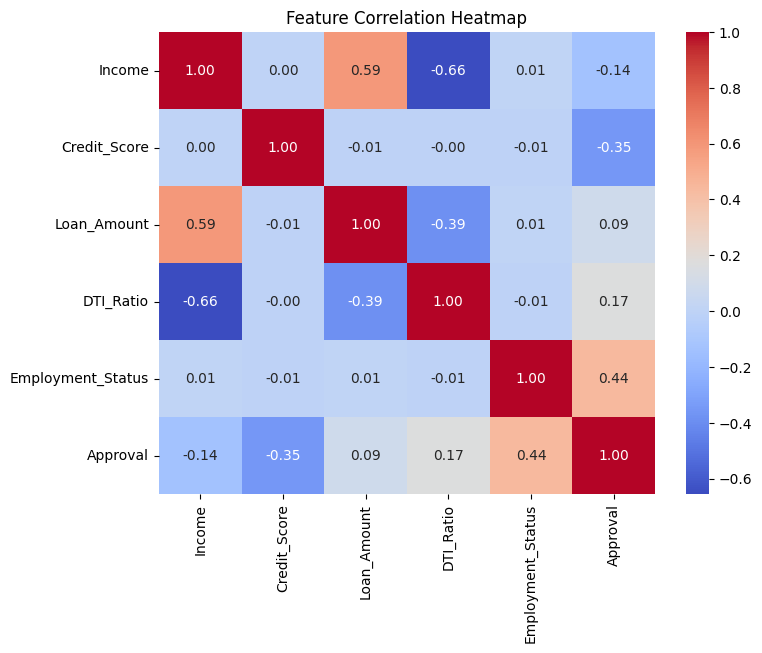

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Data Splitting for model train and test

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [114]:
X_train.shape,y_train.shape, X_test.shape, y_test.shape

((28093, 5), (28093,), (12041, 5), (12041,))

#Model development

In [115]:
model = KNeighborsClassifier(n_neighbors=7)

In [116]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

#Prediction using testing data

In [117]:
y_pred = model.predict(X_test)

In [118]:
y_pred

array([1, 0, 0, ..., 0, 1, 1])

#Model Evaluation

#Accuracy

In [119]:
accu = accuracy_score(y_test, y_pred)
accu

0.987625612490657

#Confusion matrics

In [120]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[6057,    6],
       [ 143, 5835]])

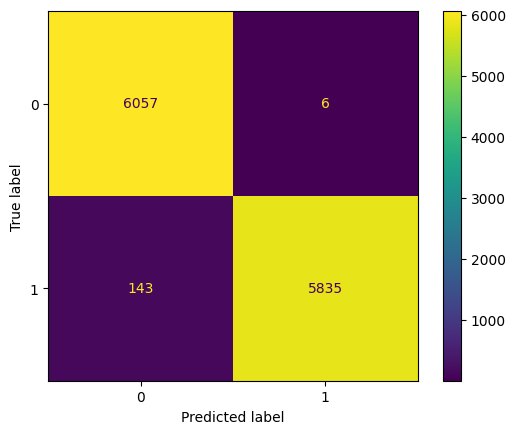

In [121]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()

In [122]:
crp = classification_report(y_test, y_pred)
print(crp)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6063
           1       1.00      0.98      0.99      5978

    accuracy                           0.99     12041
   macro avg       0.99      0.99      0.99     12041
weighted avg       0.99      0.99      0.99     12041



#Also test with other algorithms

In [123]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [124]:
nb = GaussianNB()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=10)

best_accuracy = 0
best_model_name = ''
models = [nb, dt, rf]

for model in models:
  print('Current model: ', model)
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)

  acc = accuracy_score(y_test, y_pred)
  print(acc*100)

  if acc > best_accuracy:
    best_accuracy = acc
    best_model_name = type(model).__name__
    joblib.dump(model, 'best_model.pkl')
    print(model, 'saved successfully...')


  print('\n###########################################')
  print('\n###########################################')
  print(f'\n Best model: {best_model_name} with accuracy: {best_accuracy}')

Current model:  GaussianNB()
84.24549456025247
GaussianNB() saved successfully...

###########################################

###########################################

 Best model: GaussianNB with accuracy: 0.8424549456025247
Current model:  DecisionTreeClassifier()
99.70932646790133
DecisionTreeClassifier() saved successfully...

###########################################

###########################################

 Best model: DecisionTreeClassifier with accuracy: 0.9970932646790134
Current model:  RandomForestClassifier(max_depth=10)
98.61307200398637

###########################################

###########################################

 Best model: DecisionTreeClassifier with accuracy: 0.9970932646790134


In [125]:
# best model is Decision Tree Classifier

#Save the same encoder for Employment status and Approval columns

In [126]:
print(encoder_approval.classes_)

['Approved' 'Rejected']


In [127]:
print(encoder_emp_status.classes_)

['employed' 'unemployed']


In [128]:
joblib.dump(encoder_approval, 'encoder_approval.pkl')

['encoder_approval.pkl']

In [129]:
joblib.dump(encoder_emp_status, 'encoder_employment_status.pkl')

['encoder_employment_status.pkl']